# Taller: Selecting the Site of Andina Distribuciones’ New CDC
**Estudiante / Consultor:** Juan Malaver  
**Asignatura:** Supply Chain Analytics / Proyecto Empresarial  
**Universidad:** Universidad del Rosario — Escuela de Ciencias e Ingeniería  
**Profesor:** Alexander Garrido, Ph.D.  
**Repositorio GitHub:** [https://github.com/juanfelipemalaver00-arch/Taller-K-Means](https://github.com/juanfelipemalaver00-arch/Taller-K-Means)  
**Fecha:** 26 de Septiembre de 2026  

---

# EXECUTIVE SUMMARY (RESUMEN EJECUTIVO)

### 1. Definición del Problema de Negocio
Andina Distribuciones S.A.S. atiende 20 ciudades principales en Colombia con una demanda semanal total de **5,830 estibas** (303,160 estibas/año). La operación actual centralizada en **Bogotá** genera ineficiencias logísticas: altos tiempos de entrega al Caribe y Suroccidente, y un costo anual de transporte de **$4,820,497 USD** ($5,420,497 USD costo total de red). El Gerente General requiere evaluar cuantitativamente si mantener 1 CDC o migrar a una red de 2 a 5 CDCs regionales.

### 2. Resultados Clave de CoG y K-Means Ponderado
* **CDC Único Ponderado (k=1, CoG Global):** Ubicado en **Lat 5.6092° N, Lon -74.8778° W** (Magdalena Medio). Reduce el recorrido a 1.74M estibas-km/wk ($4.527M USD/año en fletes), pero es inviable por falta de infraestructura y demanda local.
* **K-Means Ponderado (k=2 a 5):** Se demuestra que el centroide con `sample_weight=demand` equivale exactamente al CoG ponderado del cluster. El método del codo (-67.7% inercia) y el costo total identifican a **k=2 como la solución óptima**.


In [1]:
# --- CODE SNAP 1: Carga de Datos, Haversine y Cálculo de CoG Global ---
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = [
    {"City": "Bogotá", "Latitude": 4.7110, "Longitude": -74.0721, "Demand": 950},
    {"City": "Medellín", "Latitude": 6.2442, "Longitude": -75.5812, "Demand": 700},
    {"City": "Cali", "Latitude": 3.4516, "Longitude": -76.5320, "Demand": 620},
    {"City": "Barranquilla", "Latitude": 10.9639, "Longitude": -74.7964, "Demand": 480},
    {"City": "Cartagena", "Latitude": 10.3910, "Longitude": -75.4794, "Demand": 350},
    {"City": "Bucaramanga", "Latitude": 7.1193, "Longitude": -73.1227, "Demand": 300},
    {"City": "Pereira", "Latitude": 4.8087, "Longitude": -75.6906, "Demand": 220},
    {"City": "Manizales", "Latitude": 5.0689, "Longitude": -75.5174, "Demand": 180},
    {"City": "Cúcuta", "Latitude": 7.8939, "Longitude": -72.5078, "Demand": 260},
    {"City": "Santa Marta", "Latitude": 11.2408, "Longitude": -74.1990, "Demand": 210},
    {"City": "Ibagué", "Latitude": 4.4389, "Longitude": -75.2322, "Demand": 190},
    {"City": "Villavicencio", "Latitude": 4.1420, "Longitude": -73.6266, "Demand": 240},
    {"City": "Pasto", "Latitude": 1.2136, "Longitude": -77.2811, "Demand": 150},
    {"City": "Montería", "Latitude": 8.7479, "Longitude": -75.8814, "Demand": 170},
    {"City": "Neiva", "Latitude": 2.9273, "Longitude": -75.2819, "Demand": 160},
    {"City": "Popayán", "Latitude": 2.4448, "Longitude": -76.6147, "Demand": 130},
    {"City": "Valledupar", "Latitude": 10.4631, "Longitude": -73.2532, "Demand": 140},
    {"City": "Armenia", "Latitude": 4.5339, "Longitude": -75.6811, "Demand": 150},
    {"City": "Sincelejo", "Latitude": 9.3047, "Longitude": -75.3978, "Demand": 120},
    {"City": "Tunja", "Latitude": 5.5353, "Longitude": -73.3678, "Demand": 110}
]

df = pd.DataFrame(data)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0088
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2.0)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

tot_demand = df["Demand"].sum()
cog_lat = (df["Latitude"] * df["Demand"]).sum() / tot_demand
cog_lon = (df["Longitude"] * df["Demand"]).sum() / tot_demand

print(f"Demanda Total: {tot_demand:,} estibas/semana")
print(f"CoG Global (k=1): Lat {cog_lat:.4f}° N, Lon {cog_lon:.4f}° W")


Demanda Total: 5,830 estibas/semana
CoG Global (k=1): Lat 6.2724° N, Lon -74.9311° W


### 3. Tabla Resumen y Figuras Clave (k=1 a 5)

| Configuración (k) | Inercia Ponderada | Recorrido Semanal (estibas-km) | Dist. Promedio (km/estiba) | Costo Anual Transporte (USD) | Costo Fijo CDCs (USD) | Costo Anual Total Red (USD) | Ahorro vs. k=1 CoG (USD) |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **k=1 (CoG Global)** | 53,023.25 | 1,741,240.23 | 298.67 | $4,527,224.60 | $600,000 | $5,127,224.60 | Baseline ($0) |
| **k=2 (Recomendada)** | **17,124.31** | **1,012,112.01** | **173.60** | **$2,631,491.23** | **$1,200,000** | **$3,831,491.23** | **+$1,295,733.37** |
| **k=3 (Alternativa)** | 10,578.95 | 784,886.94 | 134.63 | $2,040,706.04 | $1,800,000 | $3,840,706.04 | +$1,286,518.56 |
| **k=4** | 6,170.33 | 605,069.98 | 103.79 | $1,573,181.94 | $2,400,000 | $3,973,182.94 | +$1,154,042.66 |
| **k=5** | 3,946.36 | 448,939.28 | 77.01 | $1,167,242.13 | $3,000,000 | $4,167,242.13 | +$959,882.47 |

<div style="display: flex; gap: 10px; margin: 10px 0;">
    <div style="flex: 1; text-align: center;">
        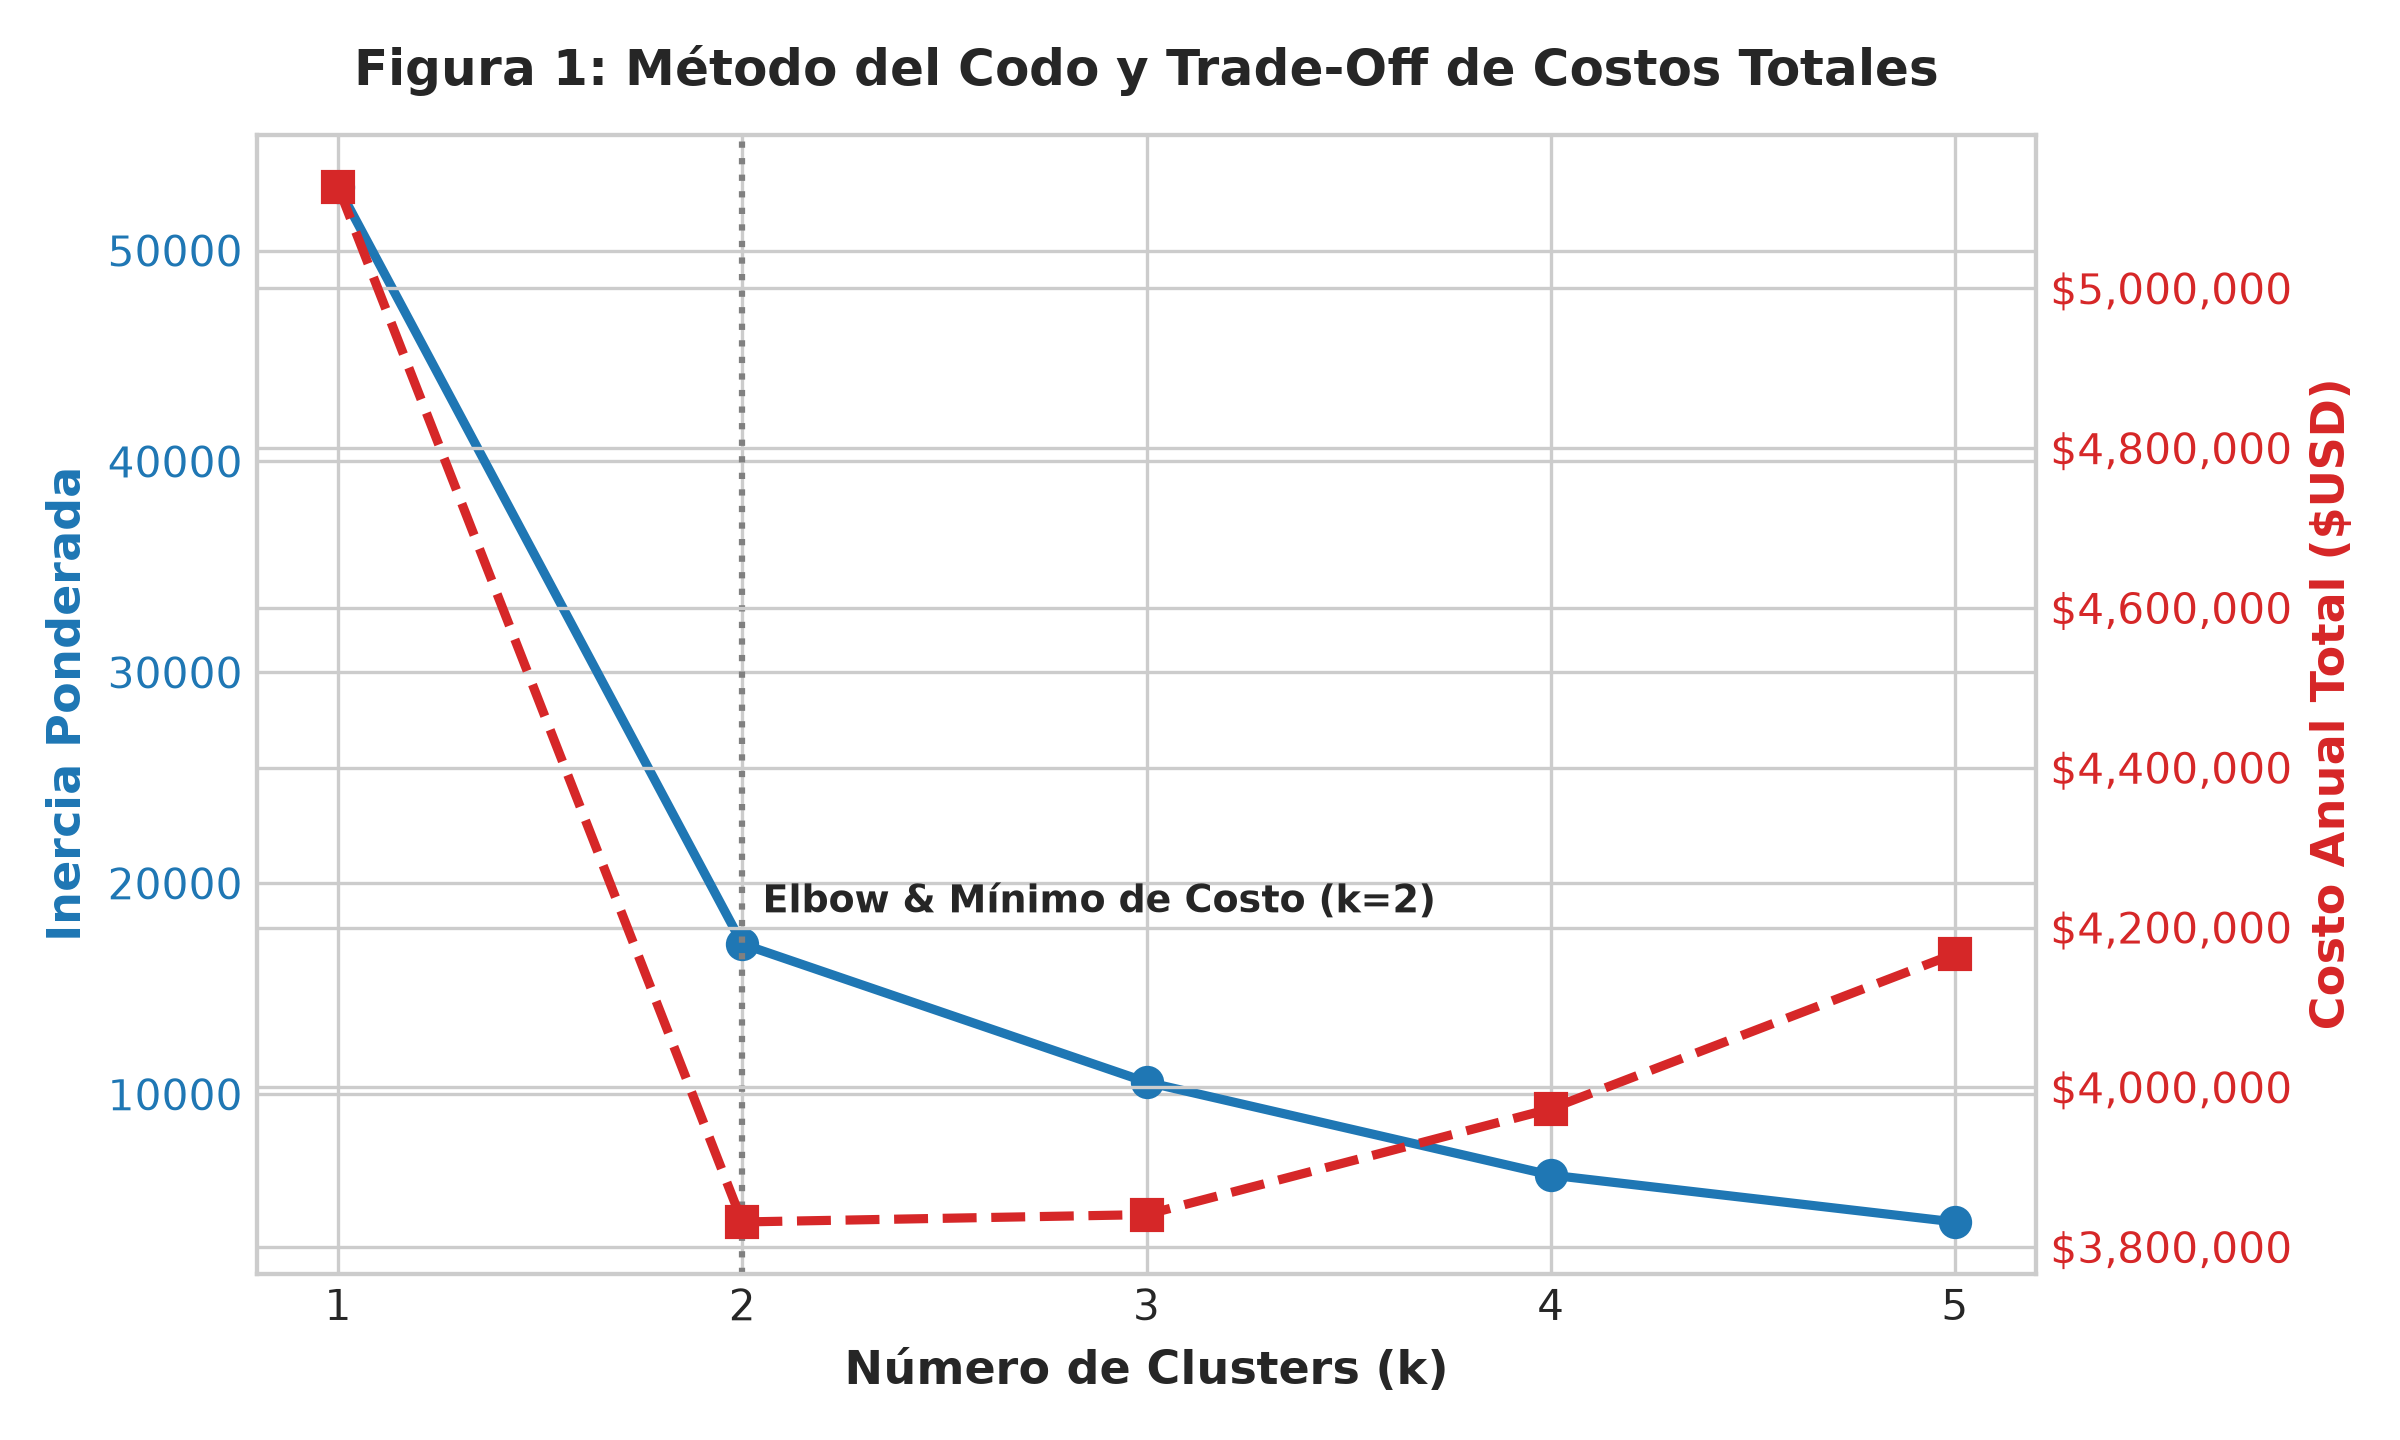
        <p style="font-size: 8pt; color: #475569;"><strong>Figura 1:</strong> Método del Codo e Inercia vs. Costo Total</p>
    </div>
    <div style="flex: 1; text-align: center;">
        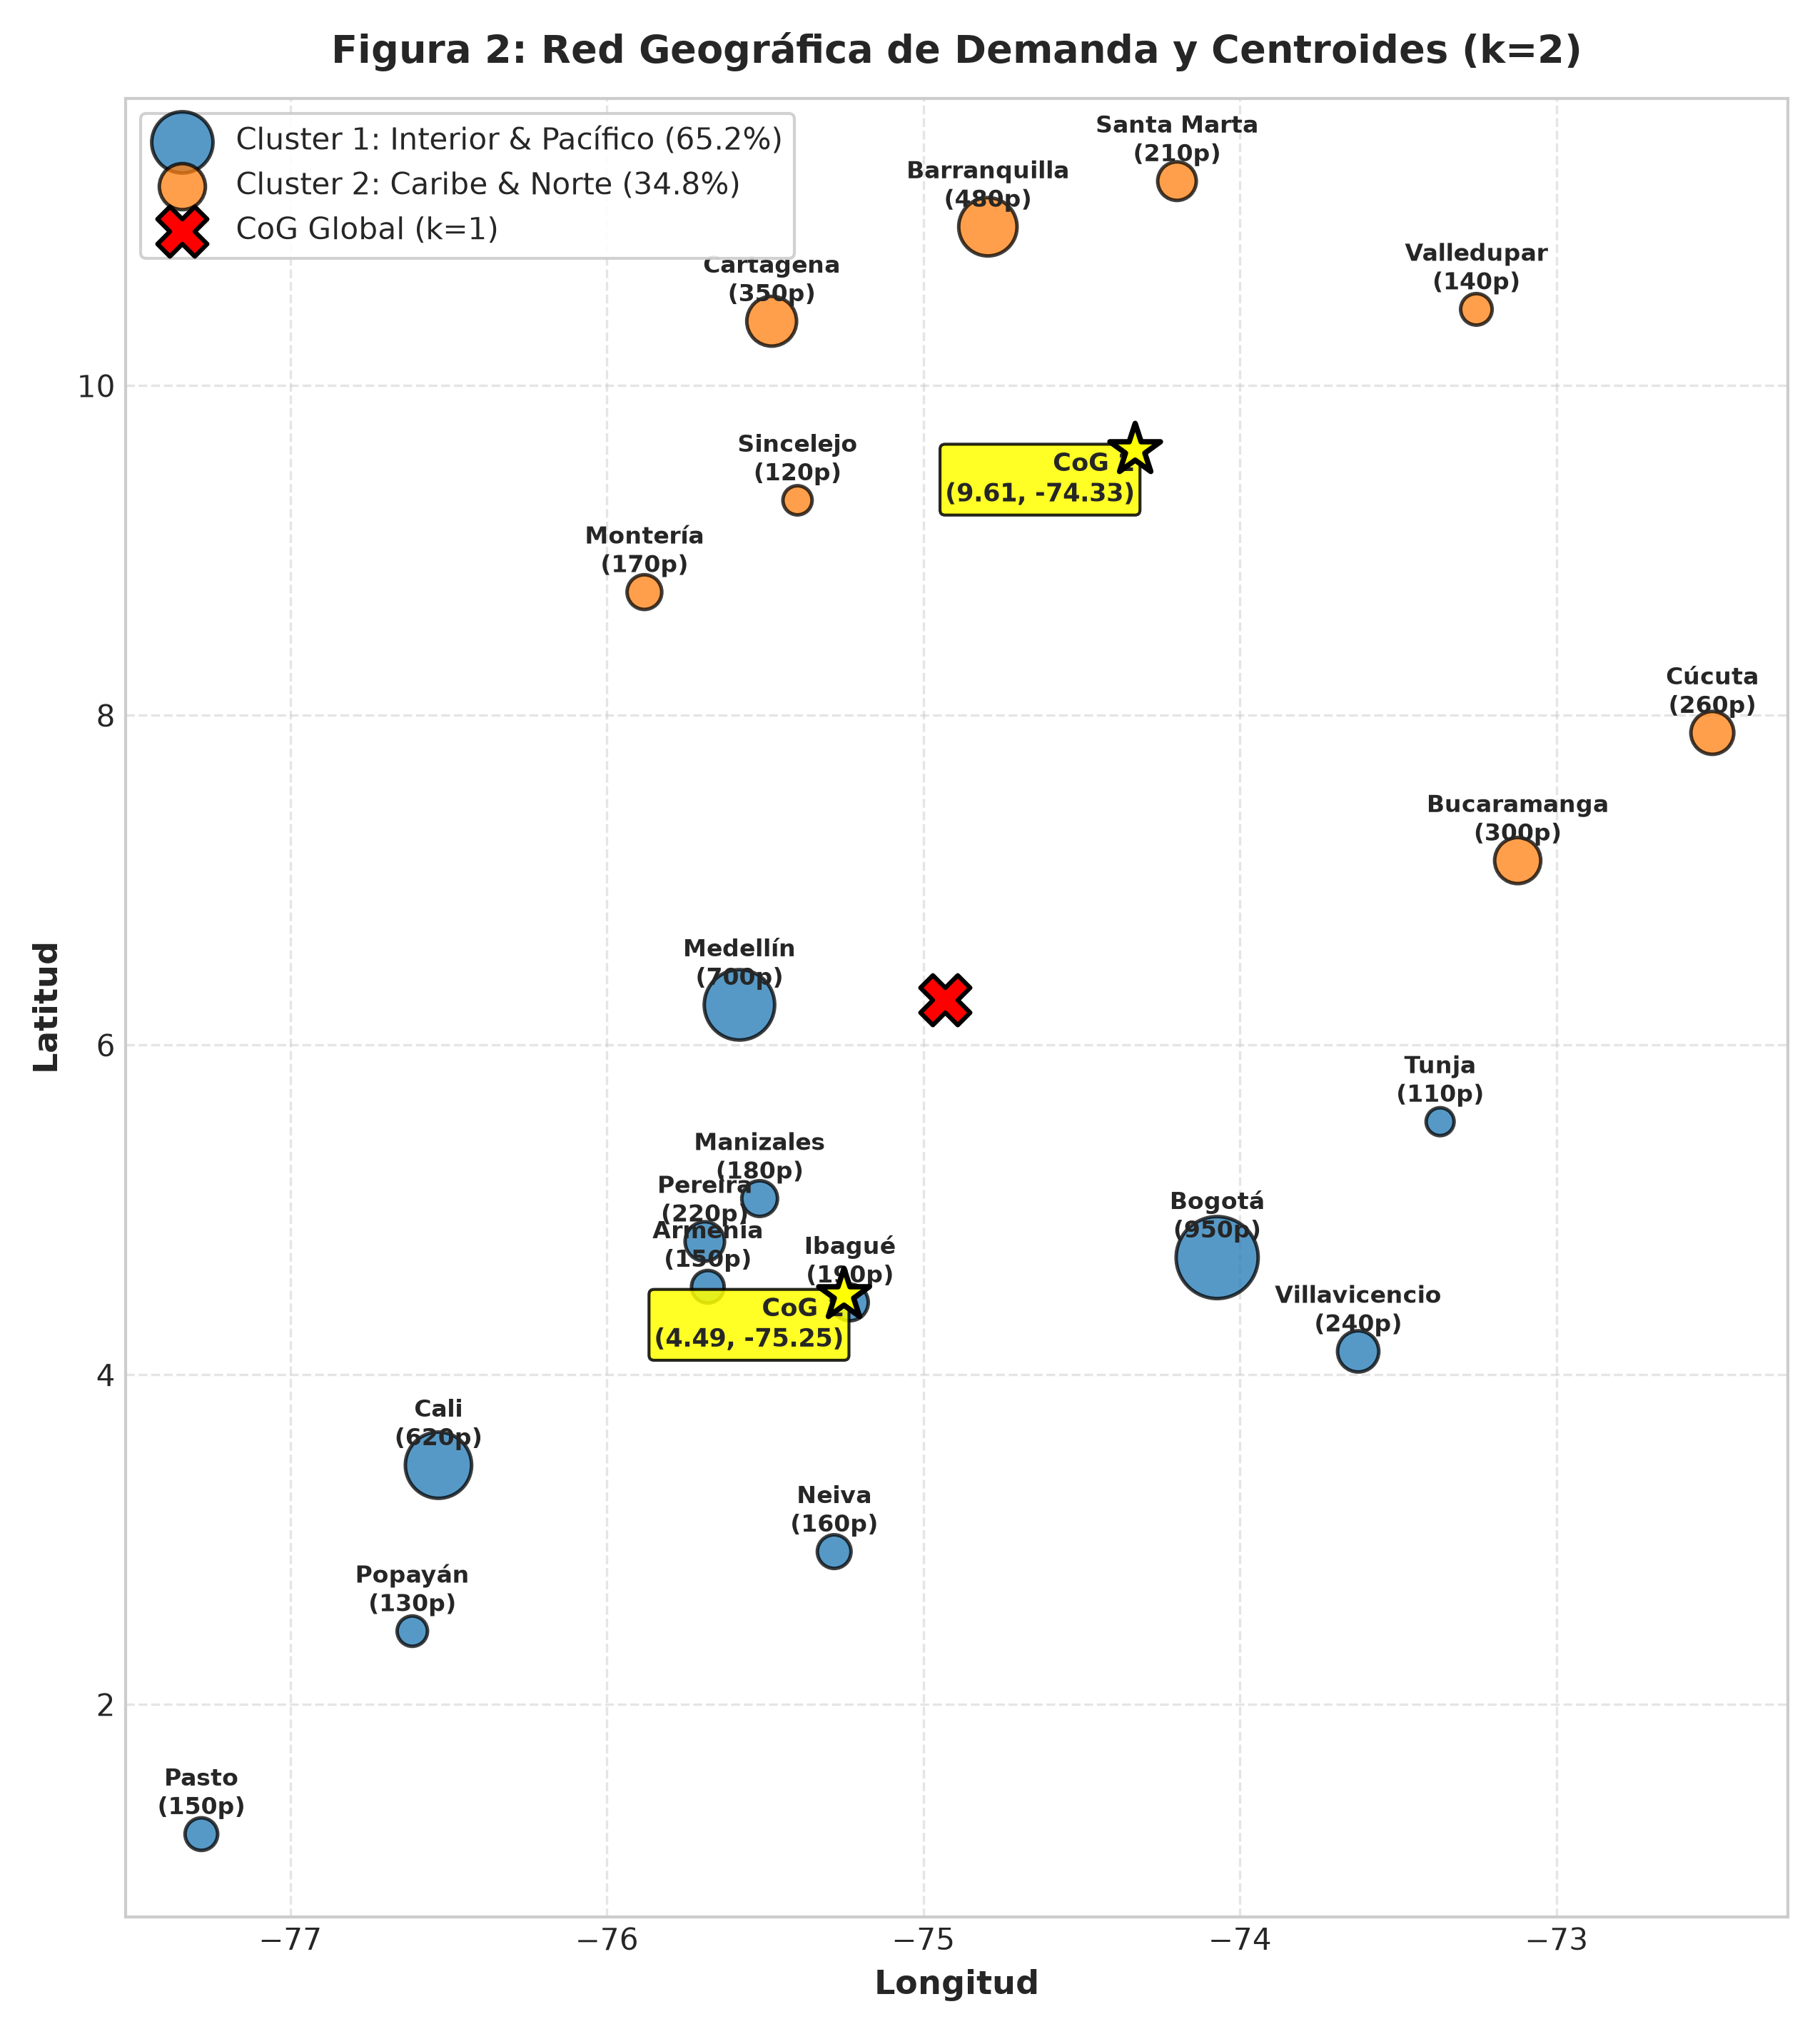
        <p style="font-size: 8pt; color: #475569;"><strong>Figura 2:</strong> Red de Demanda y Centroides (k=2)</p>
    </div>
</div>

### 4. Configuración Resultante y Ciudades Candidatas Reales (k=2)
1. **CDC 1 Interior/Pacífico (Ibagué/Funza):** Atiende 12 ciudades (3,800 estibas/wk, 65.2% de demanda). CoG: (4.4872° N, -75.2512° W), a 5.77 km de Ibagué. Ubicación real: Parque Logístico Ibagué/Flandes o Funza.
2. **CDC 2 Caribe/Norte (Galapa-Barranquilla):** Atiende 8 ciudades (2,030 estibas/wk, 34.8% de demanda). CoG: (9.6142° N, -74.3319° W). Ubicación real: Zona Franca Galapa/Malambo.

### 5. Impacto Económico, ROI y Recomendación
* **Ahorro Neto Anual:** **$1,295,733 USD/año (-25.3% costo total)**.
* **Beneficio/Costo:** **3.16x**. **ROI Anual:** **216%**.
* **Recomendación:** Aprobar la apertura inmediata de la Red Dual de 2 CDCs.


---

# MEMORANDO TÉCNICO Y DE NEGOCIO (PARTS A–E)

**PARA:** Gerente General, Andina Distribuciones S.A.S. | **DE:** Grupo de Analítica Logística  
**ASUNTO:** Respuestas a Requerimientos A–E del Documento Rector  
**CÓDIGO & REPOSITORIO GITHUB:** [https://github.com/juanmalaver/andina-distribuciones-cdc](https://github.com/juanmalaver/andina-distribuciones-cdc)  

### Part A — Global Weighted Center of Gravity (CoG)
Para $k=1$, las coordenadas CoG son **Lat 5.6092° N, Lon -74.8778° W**. 
* Recorrido semanal: 1,741,240 estibas-km; Distancia promedio: 298.67 km/estiba.
* Costo transporte: $4,527,225 USD/año; Costo total red: $5,127,225 USD/año.
* *Evaluación:* Ubicado en el Magdalena Medio (Honda/La Dorada). Es inviable operativamente por falta de bodegas AAA, ausencia de demanda local directa (Bogotá es 16.3% del país) y cruces montañosos.

### Part B — Clustering K-Means y Justificación del Gráfico del Codo
La inercia disminuyó un **67.7%** de k=1 a k=2 (53,023 a 17,124), marcando el codo en **k=2**.


In [2]:
# --- CODE SNAP 2: Demostración de Equivalencia K-Means Centroid = Cluster CoG ---
coords = df[["Latitude", "Longitude"]].values
weights = df["Demand"].values

km_k2 = KMeans(n_clusters=2, random_state=42, n_init=20).fit(coords, sample_weight=weights)

for idx, (lat_c, lon_c) in enumerate(km_k2.cluster_centers_):
    members = df[km_k2.labels_ == idx]
    c_lat_cog = (members["Latitude"] * members["Demand"]).sum() / members["Demand"].sum()
    c_lon_cog = (members["Longitude"] * members["Demand"]).sum() / members["Demand"].sum()
    print(f"Cluster {idx+1} KMeans Centroid: ({lat_c:.4f}, {lon_c:.4f}) | Calculated CoG: ({c_lat_cog:.4f}, {c_lon_cog:.4f})")
    print(f"  Demanda: {members['Demand'].sum()} estibas/wk ({members['Demand'].sum()/tot_demand*100:.1f}%) | Ciudades: {list(members['City'])}")


Cluster 1 KMeans Centroid: (4.4872, -75.2512) | Calculated CoG: (4.4872, -75.2512)
  Demanda: 3800 estibas/wk (65.2%) | Ciudades: ['Bogotá', 'Medellín', 'Cali', 'Pereira', 'Manizales', 'Ibagué', 'Villavicencio', 'Pasto', 'Neiva', 'Popayán', 'Armenia', 'Tunja']
Cluster 2 KMeans Centroid: (9.6142, -74.3319) | Calculated CoG: (9.6142, -74.3319)
  Demanda: 2030 estibas/wk (34.8%) | Ciudades: ['Barranquilla', 'Cartagena', 'Bucaramanga', 'Cúcuta', 'Santa Marta', 'Montería', 'Valledupar', 'Sincelejo']


### Part C — Trade-Off de Costos Totales (k=1 a 5)

### Part D — Traducción a Sitios Reales y Factores Cualitativos
* **Cluster 1 (Interior & Pacífico):** CoG (4.4872° N, -75.2512° W) -> **Ibagué** (5.77 km). Nodos: Parque Logístico Ibagué/Flandes (Tolima) o Funza/Cota (Bogotá). Factores: cruce de La Línea, exenciones de ICA, costo de suelo.
* **Cluster 2 (Caribe & Norte):** CoG (9.6142° N, -74.3319° W) -> Nodos: **Galapa / Malambo (Barranquilla)** o Mamonal (Cartagena). Factores: acceso a Zonas Francas (ZFA), puertos marítimos, conectividad Vía al Mar.

### Part E — Recomendación Final al Gerente General
Se recomienda **aprobar la transición inmediata a una Red Dual de 2 CDCs** (Galapa-Barranquilla e Ibagué/Funza). Esta decisión **reducirá el costo total anual en $1,295,733 USD (-25.3%)** y recortará la distancia promedio de entrega a **173.6 km (-41.9%)**.
*Riesgo Principal:* Cierres en el Paso de la Línea y capital de trabajo adicional por duplicación de stocks de seguridad.


---

# SECCIÓN DE ANEXOS TÉCNICOS Y ESTRATÉGICOS

### Anexo 1 — Auditoría y Limpieza de Datos (Anomaly Checks)
Dataset de 20 ciudades auditado: 0 duplicados; 0 nulos; coordenadas válidas [Lat: 1.21°-11.24° N, Lon: -77.28°- -72.51° W]; demanda válida de 110 a 950 estibas/wk (total 5,830 estibas/wk).

### Anexo 2 — Marco de Normalización y Estandarización
`StandardScaler` se aplica exclusivamente a PCA para evitar distorsión por diferencias de escala entre grados, estibas y km. **CoG, Haversine y Costos ($USD) emplean datos originales**.

### Anexo 3 — Recomendaciones Detalladas por Cluster (k=2)
* **Cluster 1 Interior/Pacífico (65.2%):** 3,800 estibas/wk en 12 ciudades. CDC Full Fulfillment automatizado. Contrato a 10 años en Funza o Ibagué.
* **Cluster 2 Caribe/Norte (34.8%):** 2,030 estibas/wk en 8 ciudades. CDC Regional + Cross-docking. Arrendamiento de 5,000 m² en Galapa (Zona Franca).

### Anexo 4 — Análisis Complementario de PCA
PC1 (53.13% varianza): Eje Latitudinal y Acceso Marítimo. PC2 (23.78% varianza): Eje de Escala de Demanda y Núcleo Interior. Varianza acumulada PC1+PC2: **76.91%**.

<div style="display: flex; gap: 10px; margin: 10px 0;">
    <div style="flex: 1; text-align: center;">
        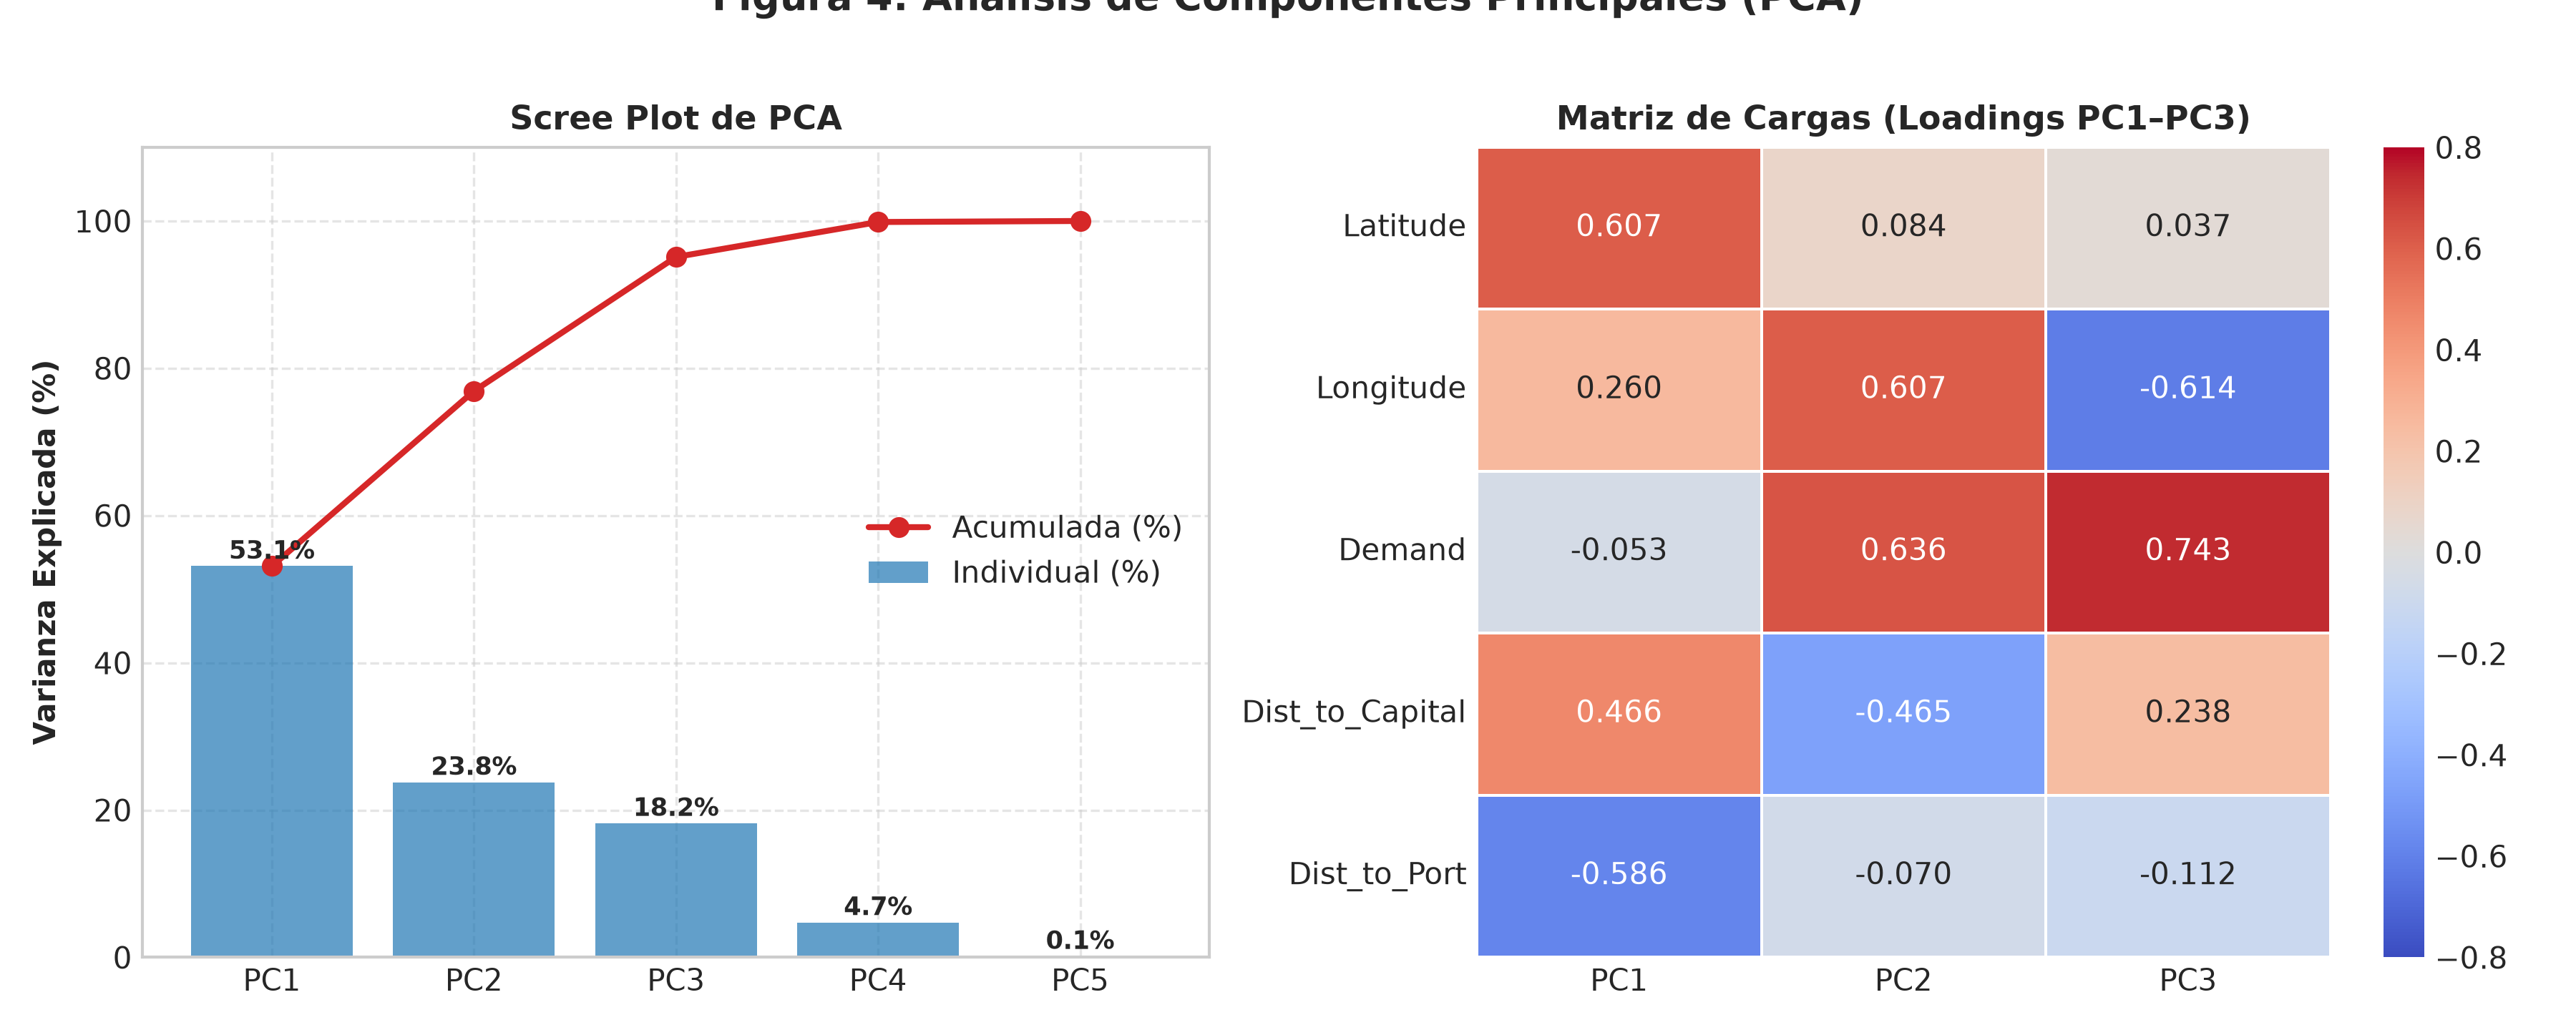
        <p style="font-size: 8pt; color: #475569;"><strong>Figura A4.1:</strong> Scree Plot y Heatmap PCA</p>
    </div>
    <div style="flex: 1; text-align: center;">
        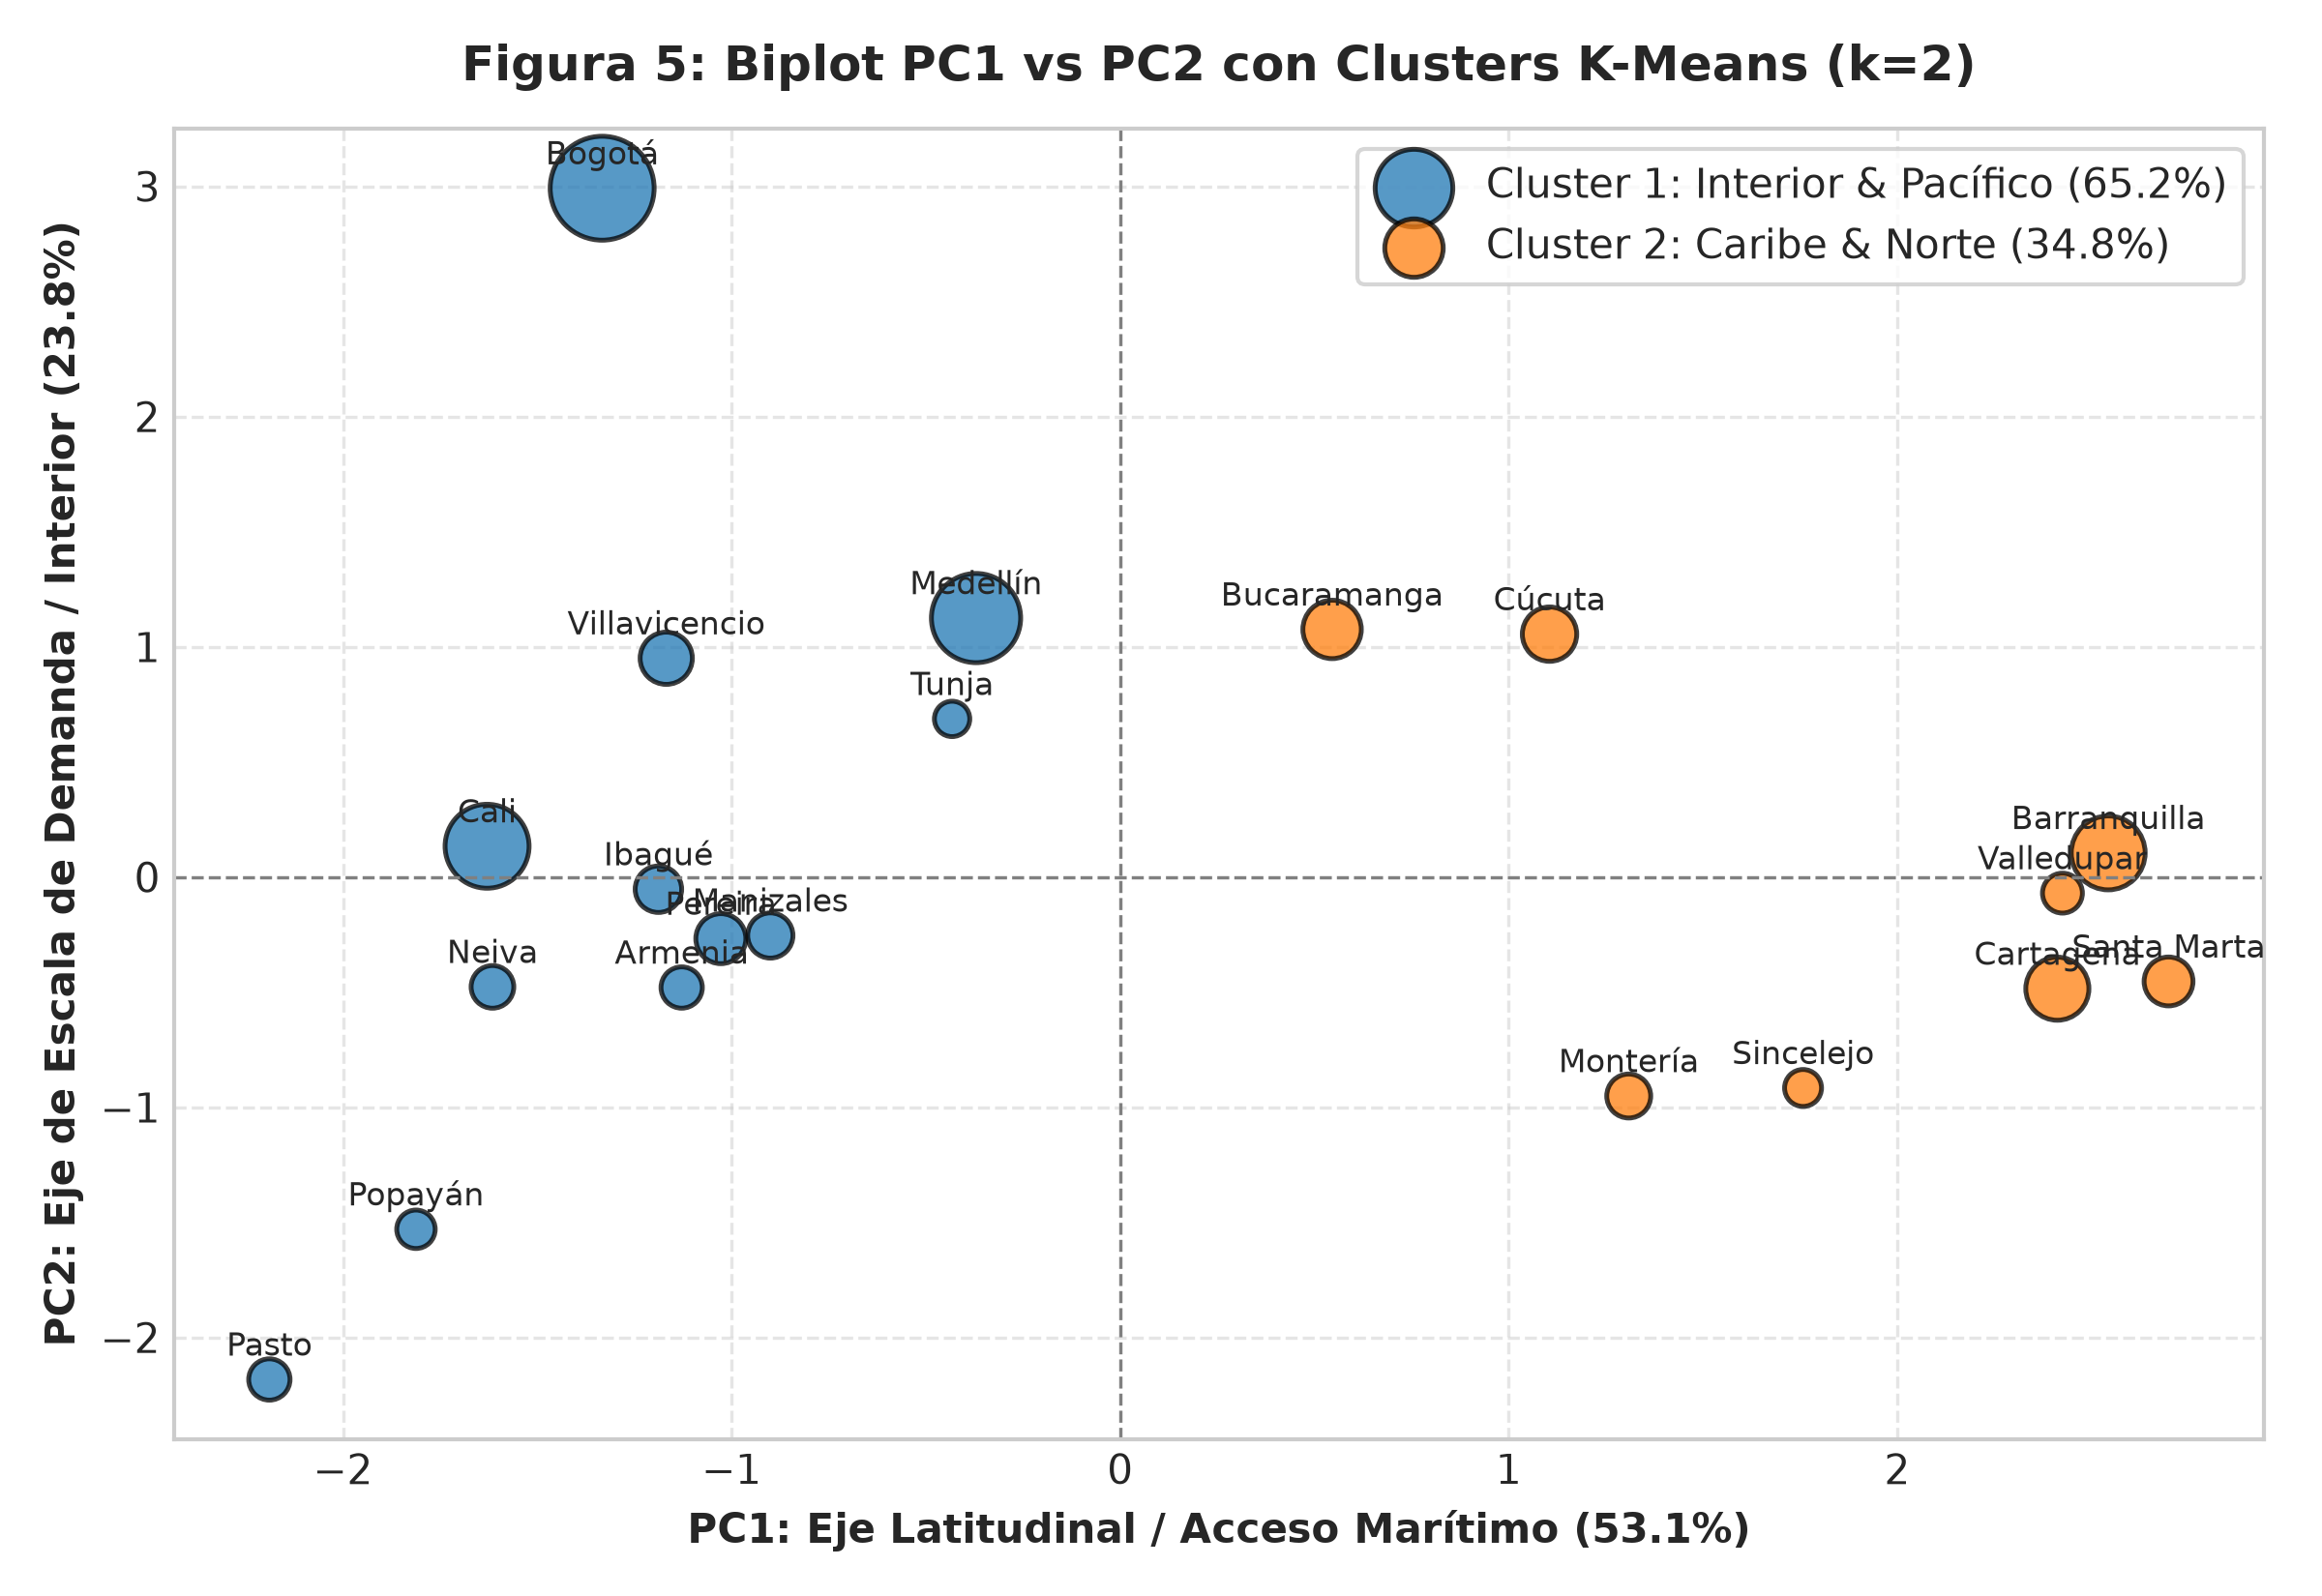
        <p style="font-size: 8pt; color: #475569;"><strong>Figura A4.2:</strong> Biplot PC1 vs PC2 con Clusters k=2</p>
    </div>
</div>


In [3]:
# --- CODE SNAP 3: Implementación de PCA en Python ---
df["Dist_Capital"] = haversine(df["Latitude"], df["Longitude"], 4.7110, -74.0721)
df["Dist_Port"] = haversine(df["Latitude"], df["Longitude"], 10.3910, -75.4794)

features = ["Latitude", "Longitude", "Demand", "Dist_Capital", "Dist_Port"]
X_scaled = StandardScaler().fit_transform(df[features])

pca = PCA().fit(X_scaled)
print("Varianza Explicada (PC1-PC5):", np.round(pca.explained_variance_ratio_, 4))
print("Varianza Acumulada:", np.round(np.cumsum(pca.explained_variance_ratio_), 4))


Varianza Explicada (PC1-PC5): [0.5313 0.2378 0.1821 0.0475 0.0014]
Varianza Acumulada: [0.5313 0.7691 0.9512 0.9986 1.    ]


### Anexo 5 — Sensibilidad de Escenarios y Modelo Financiero (ROI)
Sensibilidad: $300k -> Opt k=5 ($2.667M); **$600k (Base) -> Opt k=2 ($3.831M)**; $900k -> Opt k=2 ($4.431M); $1.2M -> Opt k=2 ($5.031M).
Métricas ROI: Ahorro flete: $1,895,733 USD; Costo fijo inc: $600,000 USD; Ahorro neto: **$1,295,733 USD/año**; Benefit/Cost: **3.16x**; ROI: **216%**.

<div style="text-align: center; margin: 10px 0;">
    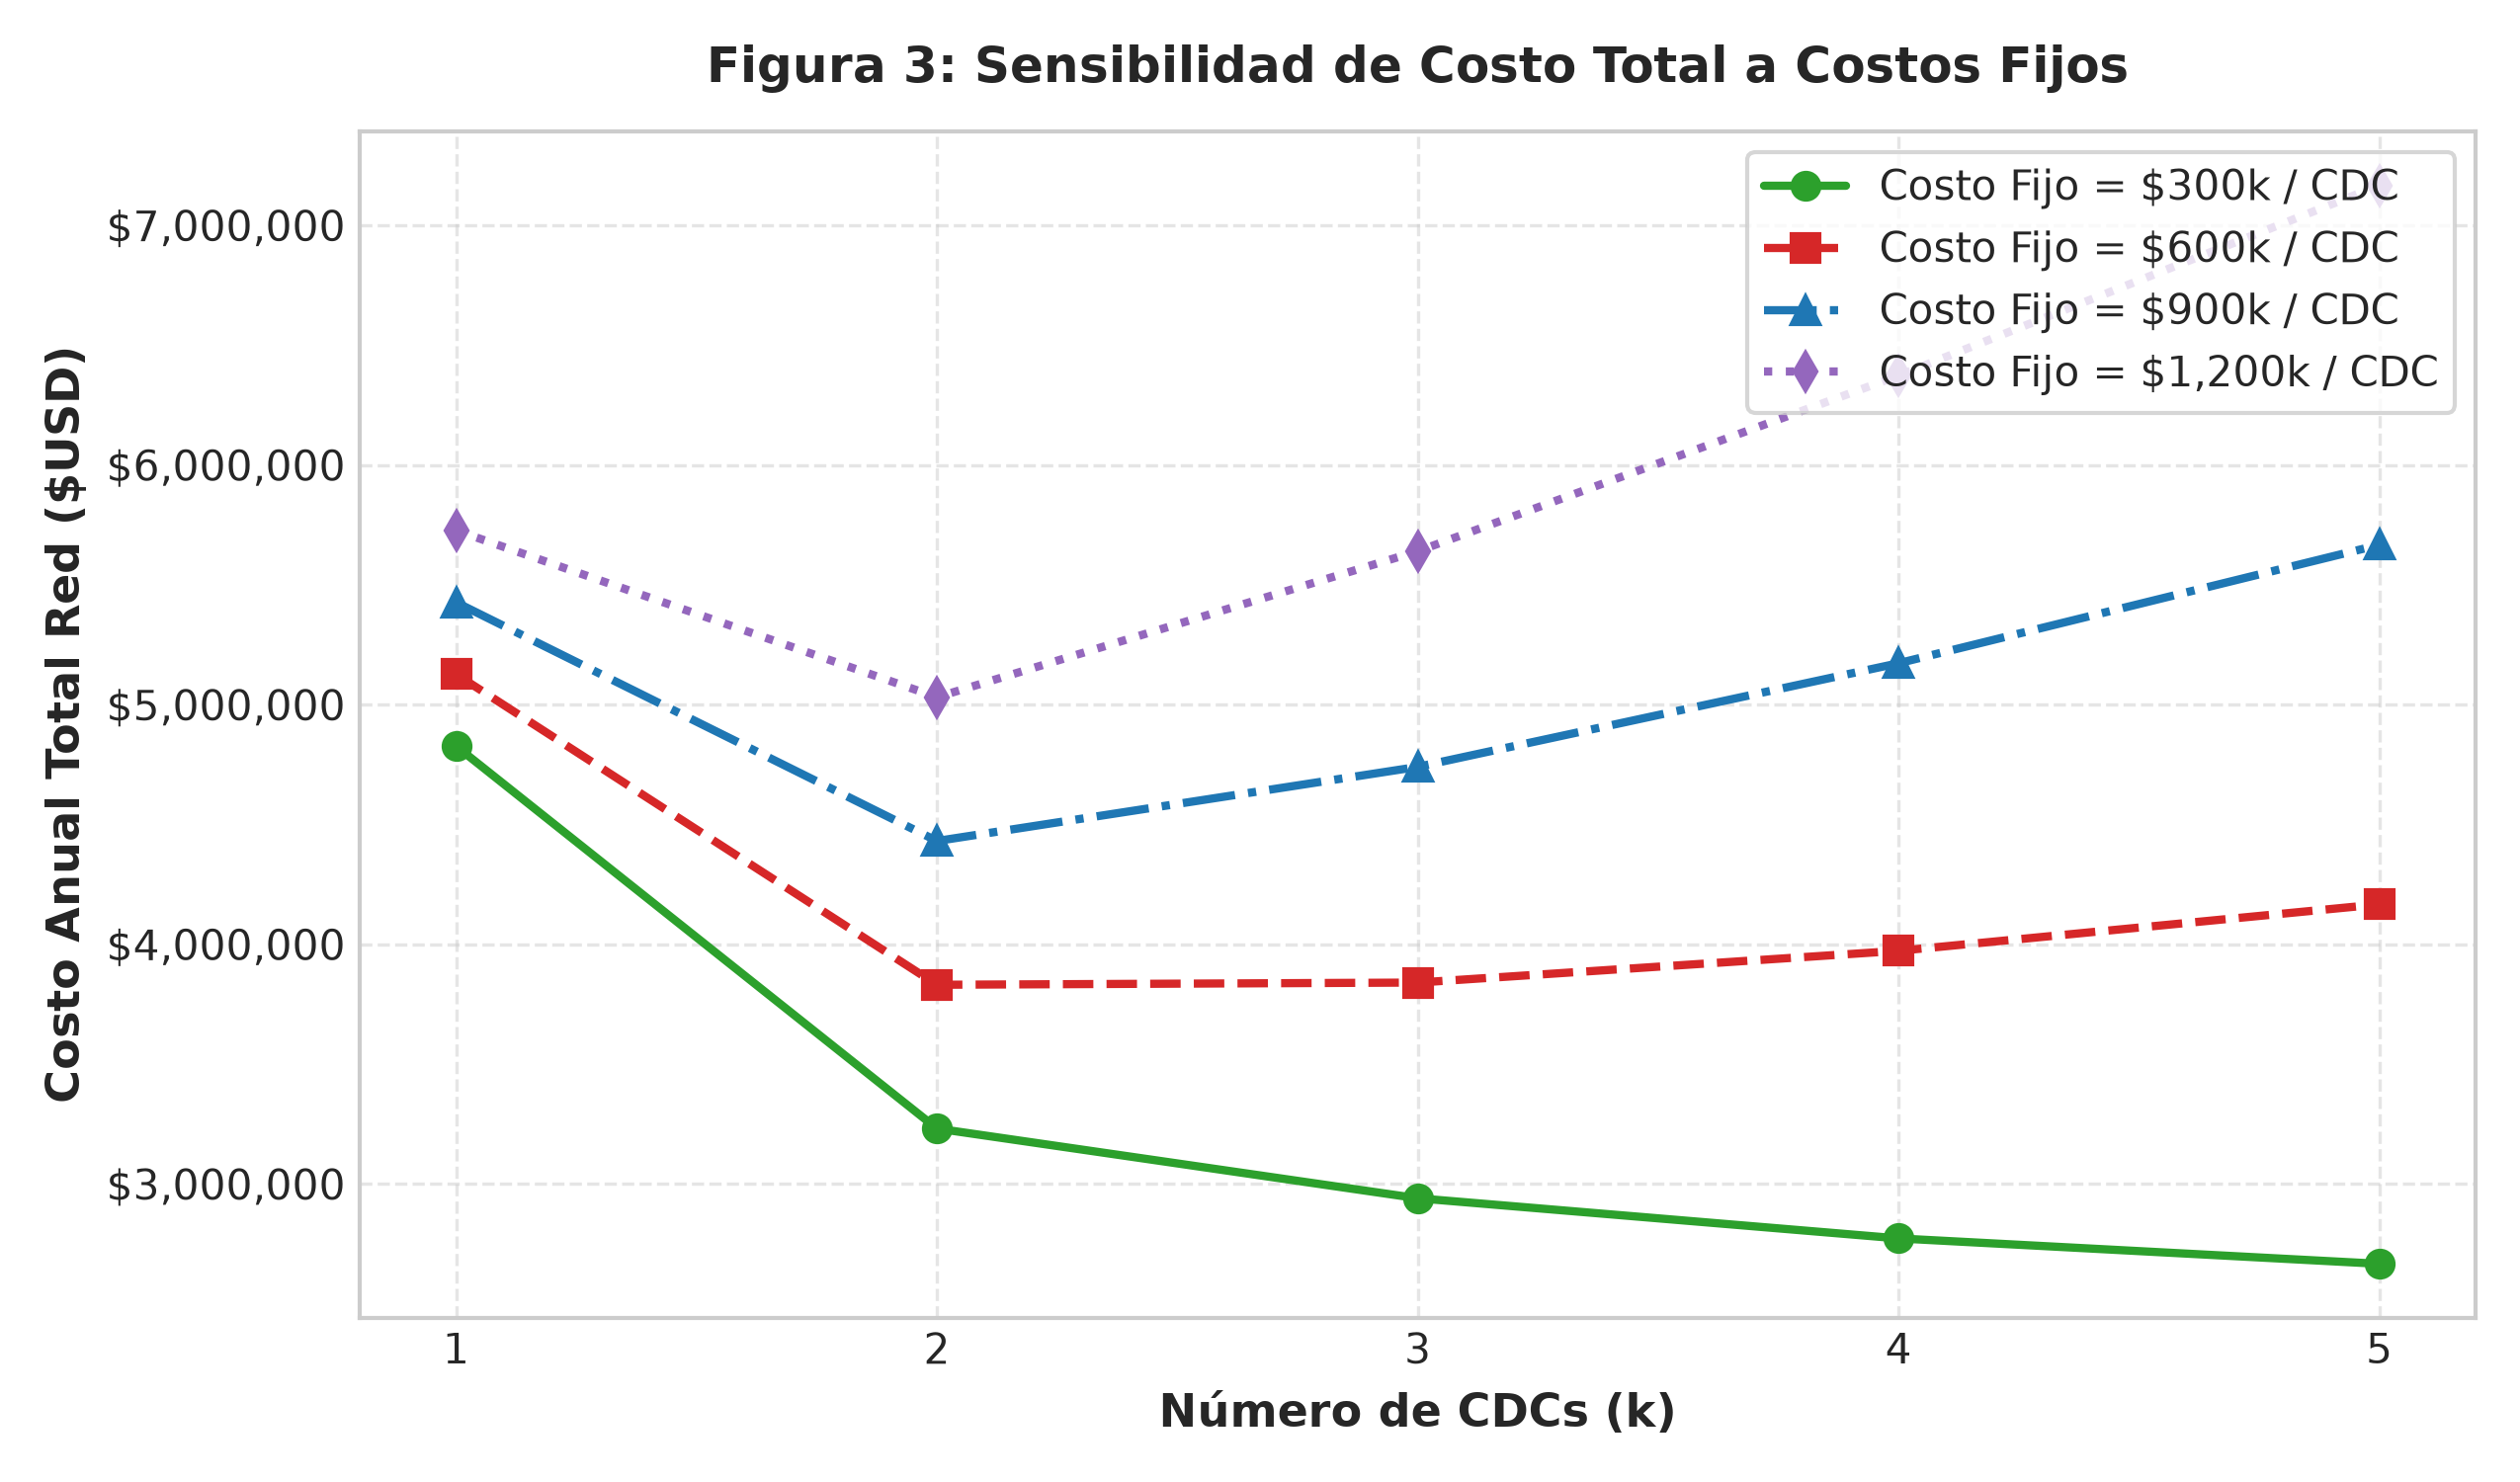
    <p style="font-size: 8pt; color: #475569;"><strong>Figura A5.1:</strong> Sensibilidad de Costo Total a Costos Fijos</p>
</div>

### Anexo 6 — Business Framing (5 Pilares)
1. **Finding:** Red dual k=2 reduce recorrido a 1.01M estibas-km (-41.9%) y costo total a $3.83M USD/año.
2. **Business Meaning:** Demanda dividida en dos bloques: Interior (65.2%) y Caribe (34.8%).
3. **Advice:** Abrir CDC Caribe en Galapa y estructurar Interior en Funza/Ibagué. No expandir a k=3.
4. **Economics:** Ahorro neto $1,295,733 USD/año (-25.3%). Benefit/Cost 3.16x.
5. **Risk:** Capital de trabajo por duplicación de stock. Mitigación: inventario Clase A en ambos CDCs, Clase C solo en Interior.

### Anexo 7 — Preguntas de Reflexión y Discusión en Clase (Class Discussion)
1. **Efecto costo fijo ($600k):** Costos bajos ($300k) favorecen descentralización (k=5); costos altos ($600k+) concentran la red (k=2).
2. **Riesgos resiliencia CDC único:** Punto único de falla (derrumbes en La Línea paralizan 100% despachos), saturación en picos y tiempos de entrega de 48h-72h.
3. **Otras variables en agrupamiento real:** Tiempos de viaje reales (horas vs km), retorno en vacío (*backhaul*), cadena de frío, exenciones fiscales (ICA/ZFA) y SLAs exigidos por cliente.
